1️⃣ Import Libraries

In [76]:
import pandas as pd
import numpy as np
import sdv

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import Normalizer
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

2️⃣ Load Dataset

In [77]:
df = pd.read_csv("C:\Heart Disease\data\heart_disease.csv")

df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


3️⃣ Dataset Information

In [78]:
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (10000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float64
 15  S

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,9971.000000,9981.000000,9970.000000,9978.000000,9975.000000,9974.000000,9978.000000,9974.000000,9980.000000
mean,49.296259,149.757740,225.425577,29.077269,6.991329,250.734409,120.142213,7.472201,12.456271
std,18.193970,17.572969,43.575809,6.307098,1.753195,87.067226,23.584011,4.340248,4.323426
min,18.000000,120.000000,150.000000,18.002837,4.000605,100.000000,80.000000,0.003647,5.000236
25%,34.000000,134.000000,187.000000,23.658075,5.449866,176.000000,99.000000,3.674126,8.723334
50%,49.000000,150.000000,226.000000,29.079492,7.003252,250.000000,120.000000,7.472164,12.409395
75%,65.000000,165.000000,263.000000,34.520015,8.531577,326.000000,141.000000,11.255592,16.140564
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037


4️⃣ Missing Value Check

In [79]:
df.isnull().sum()

Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level        20
Heart Disease Status       0
dtype: int64

5️⃣ Missing Value Handling

Numerical Columns

In [80]:
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

Categorical Columns

In [81]:
cat_cols = df.select_dtypes(include=['object', 'string']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

6️⃣ Duplicate Value Check

In [82]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


7️⃣ Remove Duplicates

In [83]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (10000, 21)


8️⃣ Encoding

In [84]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Gender_Male,...,High Blood Pressure_Yes,Low HDL Cholesterol_Yes,High LDL Cholesterol_Yes,Alcohol Consumption_Low,Alcohol Consumption_Medium,Stress Level_Low,Stress Level_Medium,Sugar Consumption_Low,Sugar Consumption_Medium,Heart Disease Status_Yes
0,56.0,153.0,155.0,24.991591,7.633228,342.0,120.142213,12.969246,12.387250,True,...,True,True,False,False,False,False,True,False,True,False
1,69.0,146.0,286.0,25.221799,8.744034,133.0,157.000000,9.355389,19.298875,False,...,False,True,False,False,True,False,False,False,True,False
2,46.0,126.0,216.0,29.855447,4.440440,393.0,92.000000,12.709873,11.230926,True,...,False,True,True,True,False,True,False,True,False,False
3,32.0,122.0,293.0,24.130477,5.249405,293.0,94.000000,12.509046,5.961958,False,...,True,False,True,True,False,False,False,False,False,False
4,60.0,166.0,242.0,20.486289,7.030971,263.0,154.000000,10.381259,8.153887,True,...,True,False,False,True,False,False,False,False,False,False


9️⃣ IQR Outlier Removal

In [85]:
num_df = df.select_dtypes(include=np.number)

Q1 = num_df.quantile(0.25)
Q3 = num_df.quantile(0.75)

IQR = Q3 - Q1

df = df[
    ~(
        (num_df < (Q1 - 1.5 * IQR)) |
        (num_df > (Q3 + 1.5 * IQR))
    ).any(axis=1)
]

print(df.shape)

(10000, 25)


🔟 Z-Score Outlier Removal

In [86]:

num_df = df.select_dtypes(include=np.number)

z_scores = np.abs(stats.zscore(num_df))

df = df[(z_scores < 3).all(axis=1)]

print(df.shape)

(10000, 25)


1️⃣1️⃣ Feature & Target

In [87]:
X = df.drop("Heart Disease Status_Yes", axis=1)

y = df["Heart Disease Status_Yes"]

1️⃣2️⃣ Min-Max Scaling

In [88]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

1️⃣3️⃣ Normalization

In [89]:
normalizer = Normalizer()

X_normalized = normalizer.fit_transform(X_scaled)

1️⃣4️⃣ Class Distribution

In [90]:
y.value_counts()

Heart Disease Status_Yes
False    8000
True     2000
Name: count, dtype: int64

1️⃣5️⃣ Data Balancing (Upsampling)

In [91]:
X_df = pd.DataFrame(X_normalized)

X_df["target"] = y.values

In [92]:
majority = X_df[X_df["target"] == False]

minority = X_df[X_df["target"] == True]

In [93]:
minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)

In [94]:
balanced_df = pd.concat(
    [majority, minority_upsampled]
)

1️⃣6️⃣ Balanced Result Check

In [95]:
balanced_df["target"].value_counts()

target
False    8000
True     8000
Name: count, dtype: int64

1️⃣7️⃣ Split Features & Target Again

In [96]:
X = balanced_df.drop("target", axis=1)

y = balanced_df["target"]

1️⃣8️⃣ Train Test Split

In [97]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(12800, 24)
(3200, 24)


1️⃣9️⃣ Heatmap

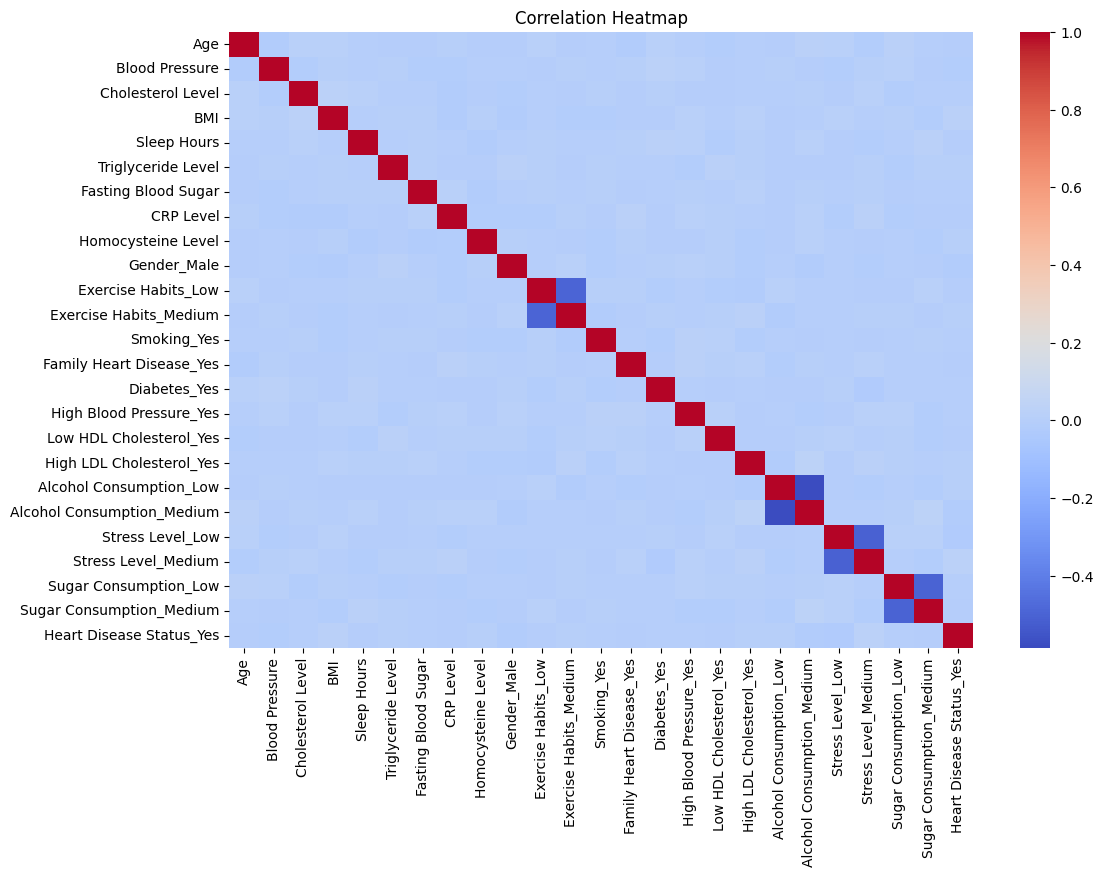

In [98]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

2️⃣0️⃣ Boxplot

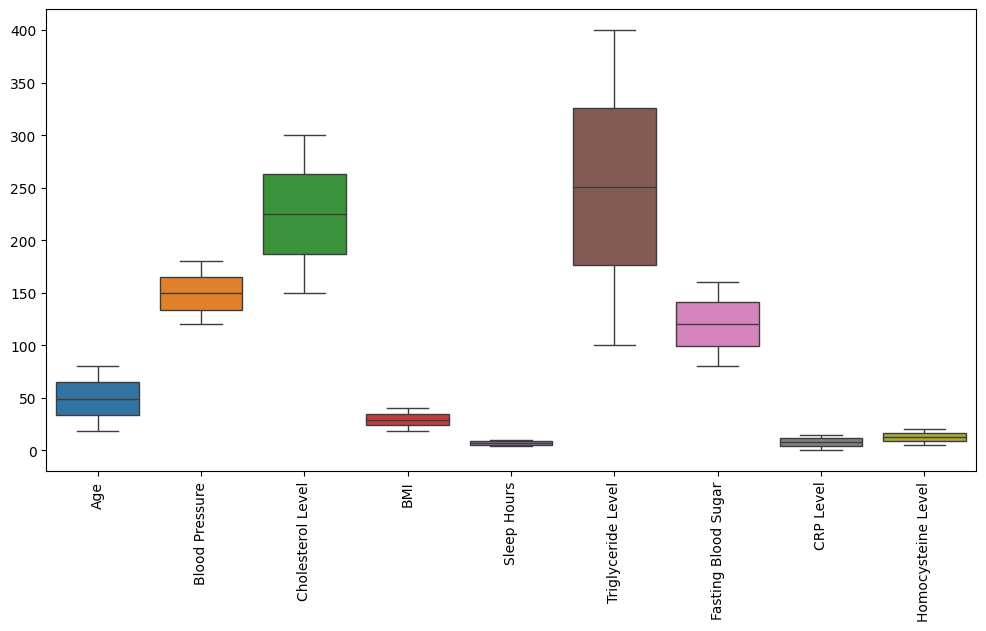

In [99]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df.select_dtypes(include=np.number))

plt.xticks(rotation=90)

plt.show()

2️⃣1️⃣ Histogram

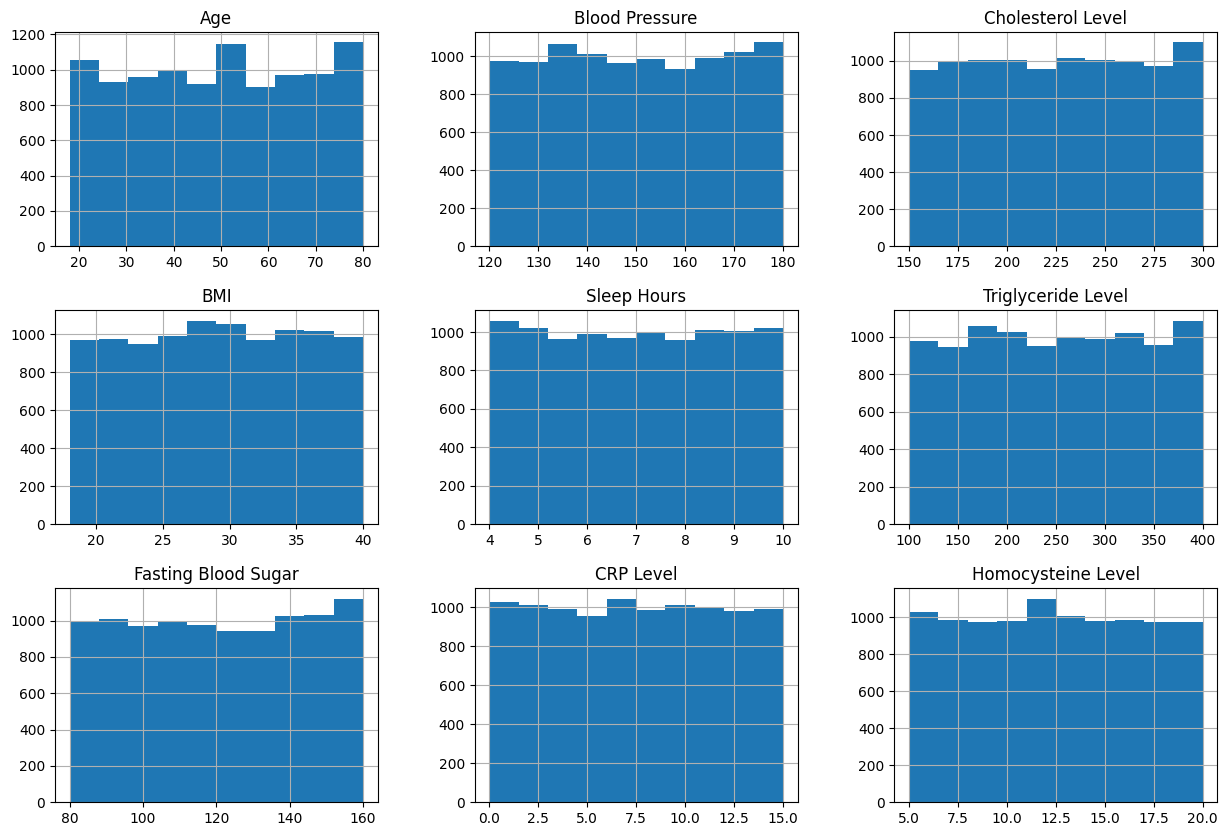

In [100]:
df.hist(
    figsize=(15,10)
)

plt.show()

2️⃣2️⃣ Simple Model + Confusion Matrix

In [101]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

In [102]:
model = DecisionTreeClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [103]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1180  424]
 [  39 1557]]


2️⃣3️⃣ Accuracy Score

In [104]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy*100)

Accuracy: 0.8553125
Accuracy (%): 85.53125


2️⃣4️⃣ Precision Score

In [105]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.7859666834931852


2️⃣5️⃣ Recall Score

In [106]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.9755639097744361


2️⃣6️⃣ F1 Score

In [107]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.8705619233994968


2️⃣7️⃣ Classification Report

In [108]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.97      0.74      0.84      1604
        True       0.79      0.98      0.87      1596

    accuracy                           0.86      3200
   macro avg       0.88      0.86      0.85      3200
weighted avg       0.88      0.86      0.85      3200



2️⃣8️⃣ Confusion Matrix Heatmap

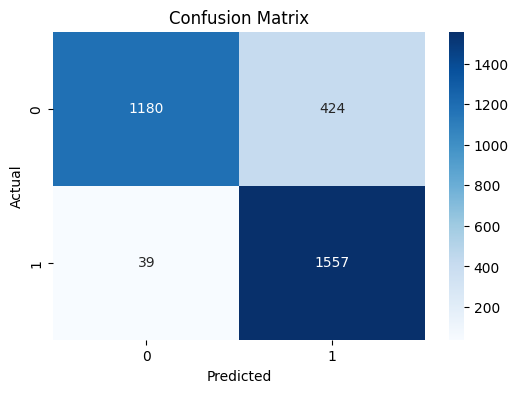

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

2️⃣9️⃣ Feature Importance

In [110]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

   Feature  Importance
8        8    0.082663
0        0    0.081999
4        4    0.076258
6        6    0.066409
5        5    0.066369
3        3    0.064563
2        2    0.062615
1        1    0.061443
7        7    0.060544
15      15    0.035537


3️⃣0️⃣ Feature Importance Plot

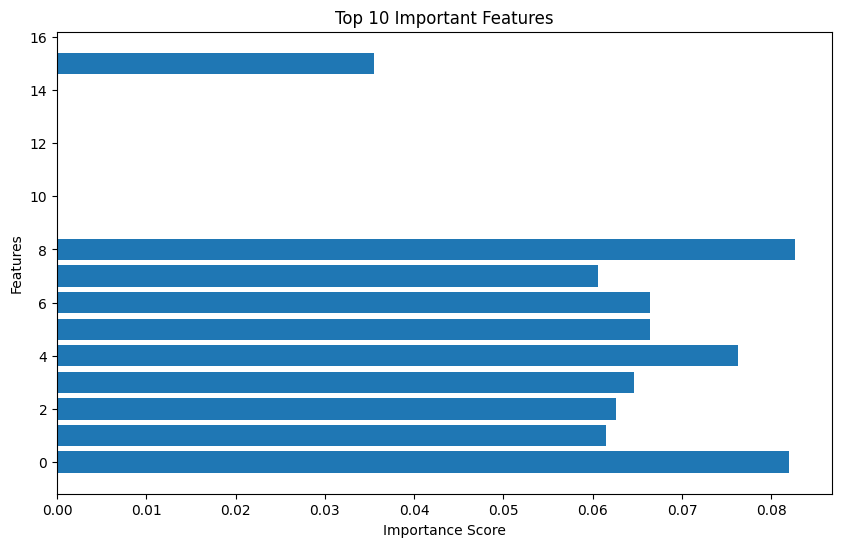

In [111]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'][:10],
    feature_importance['Importance'][:10]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Important Features")

plt.show()

Final Serial List

1  Import Libraries

2  Load Dataset

3  Dataset Information

4  Missing Value Check

5  Missing Value Handling

6  Duplicate Check

7  Remove Duplicates

8  Encoding

9  IQR Outlier Removal

10 Z-Score Outlier Removal

11 Feature & Target Selection

12 Min-Max Scaling

13 Normalization

14 Class Distribution

15 Data Balancing

16 Balanced Data Check

17 Split Features & Target

18 Train-Test Split

19 Correlation Heatmap

20 Boxplot

21 Histogram

22 Decision Tree + Confusion Matrix

23 Accuracy Score

24 Precision Score

25 Recall Score

26 F1 Score

27 Classification Report

28 Confusion Matrix Heatmap

29 Feature Importance

30 Feature Importance Plot

3️⃣1️⃣ Check Data Types

In [112]:
print(balanced_df.dtypes)

0         float64
1         float64
2         float64
3         float64
4         float64
5         float64
6         float64
7         float64
8         float64
9         float64
10        float64
11        float64
12        float64
13        float64
14        float64
15        float64
16        float64
17        float64
18        float64
19        float64
20        float64
21        float64
22        float64
23        float64
target       bool
dtype: object


3️⃣2️⃣ Fix Column Names

In [113]:
balanced_df = balanced_df.copy()

balanced_df.columns = balanced_df.columns.astype(str)

print(balanced_df.columns)

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23',
       'target'],
      dtype='object')


3️⃣3️⃣ Convert String Columns

In [114]:
for col in balanced_df.columns:

    if str(balanced_df[col].dtype) == "string":

        balanced_df[col] = balanced_df[col].astype(object)

3️⃣4️⃣ Verify Data Types

In [115]:
print(balanced_df.dtypes)

0         float64
1         float64
2         float64
3         float64
4         float64
5         float64
6         float64
7         float64
8         float64
9         float64
10        float64
11        float64
12        float64
13        float64
14        float64
15        float64
16        float64
17        float64
18        float64
19        float64
20        float64
21        float64
22        float64
23        float64
target       bool
dtype: object


3️⃣5️⃣ Create Metadata

In [116]:
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()

metadata.detect_from_dataframe(
    data=balanced_df
)

metadata

{
    "columns": {
        "0": {
            "sdtype": "numerical"
        },
        "1": {
            "sdtype": "numerical"
        },
        "2": {
            "sdtype": "numerical"
        },
        "3": {
            "sdtype": "numerical"
        },
        "4": {
            "sdtype": "numerical"
        },
        "5": {
            "sdtype": "numerical"
        },
        "6": {
            "sdtype": "numerical"
        },
        "7": {
            "sdtype": "numerical"
        },
        "8": {
            "sdtype": "numerical"
        },
        "9": {
            "sdtype": "numerical"
        },
        "10": {
            "sdtype": "numerical"
        },
        "11": {
            "sdtype": "numerical"
        },
        "12": {
            "sdtype": "numerical"
        },
        "13": {
            "sdtype": "numerical"
        },
        "14": {
            "sdtype": "numerical"
        },
        "15": {
            "sdtype": "numerical"
        },
        "16": {

3️⃣6️⃣ Save Metadata

In [118]:
metadata.save_to_json(
    "metadata.json"
)

3️⃣7️⃣ Import CTGAN

In [119]:
from sdv.single_table import CTGANSynthesizer

3️⃣8️⃣ Initialize CTGAN

In [120]:
ctgan = CTGANSynthesizer(
    metadata=metadata,
    epochs=1000
)

3️⃣9️⃣ Train CTGAN

In [121]:
ctgan.fit(
    balanced_df
)

print("CTGAN Training Completed")

CTGAN Training Completed


4️⃣0️⃣ Generate Synthetic Data

In [122]:
synthetic_ctgan = ctgan.sample(
    num_rows=1000
)

synthetic_ctgan.head()

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,target
0,0.088734,0.121515,0.006576,0.090673,0.283021,0.229951,0.272208,0.313466,0.120958,0.000000,...,0.000000,0.282728,0.000000,0.0,0.000000,0.001482,0.304973,0.000000,0.294043,True
1,0.061871,0.276633,0.099563,0.289902,0.139061,0.016827,0.011925,0.008963,0.337888,0.315793,...,0.348584,0.000000,0.000000,0.0,0.001259,0.000000,0.318419,0.310785,0.000209,False
2,0.206528,0.343877,0.028269,0.262299,0.309082,0.072167,0.089278,0.253624,0.227623,0.308089,...,0.000000,0.308057,0.000000,0.0,0.000000,0.000193,0.316670,0.000000,0.001159,True
3,0.241875,0.250370,0.044776,0.262669,0.174341,0.116702,0.036608,0.064572,0.299334,0.310188,...,0.305367,0.000000,0.310968,0.0,0.329858,0.000000,0.000000,0.316083,0.000989,False
4,0.113212,0.026160,0.100035,0.220685,0.111706,0.050156,0.100733,0.151545,0.223630,0.308789,...,0.295553,0.313009,0.299406,0.0,0.314982,0.000754,0.308590,0.000000,0.000000,True


4️⃣1️⃣ Shape Comparison

In [123]:
print("Original Dataset Shape:")
print(balanced_df.shape)

print("\nSynthetic Dataset Shape:")
print(synthetic_ctgan.shape)

Original Dataset Shape:
(16000, 25)

Synthetic Dataset Shape:
(1000, 25)


4️⃣2️⃣ Save Dataset

In [124]:
synthetic_ctgan.to_csv(
    "CTGAN_Synthetic_Data.csv",
    index=False
)

print("CTGAN Synthetic Dataset Saved")

CTGAN Synthetic Dataset Saved


4️⃣3️⃣ Statistical Comparison

In [125]:
print("Original Dataset Statistics")

display(
    balanced_df.describe()
)

print("Synthetic Dataset Statistics")

display(
    synthetic_ctgan.describe()
)

Original Dataset Statistics


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
count,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,...,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000
mean,0.166151,0.162743,0.165602,0.167131,0.164744,0.166280,0.164816,0.165154,0.165916,0.159416,...,0.160934,0.163452,0.163078,0.161750,0.082837,0.166176,0.105263,0.114621,0.111728,0.105840
std,0.096621,0.096436,0.095817,0.094275,0.096792,0.095444,0.096886,0.095212,0.096184,0.163769,...,0.163901,0.163373,0.163819,0.163227,0.144293,0.166031,0.154286,0.157476,0.156220,0.154162
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.084561,0.080192,0.084009,0.088066,0.081639,0.086029,0.080548,0.083583,0.084228,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.165342,0.162325,0.165354,0.166827,0.164962,0.164646,0.163817,0.166023,0.165384,0.000000,...,0.000000,0.267580,0.265544,0.000000,0.000000,0.271240,0.000000,0.000000,0.000000,0.000000
75%,0.246227,0.242493,0.245104,0.244940,0.245191,0.245926,0.247451,0.243540,0.245733,0.319534,...,0.320425,0.319967,0.320205,0.319540,0.264110,0.324025,0.302118,0.307076,0.304922,0.302115
max,0.476576,0.498502,0.479411,0.441226,0.451629,0.434062,0.481470,0.506057,0.467319,0.526078,...,0.491091,0.474774,0.552607,0.510753,0.543821,0.592390,0.527638,0.592390,0.547320,0.491797


Synthetic Dataset Statistics


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.143400,0.180162,0.150509,0.170850,0.185024,0.162446,0.170853,0.154175,0.162007,0.164790,...,0.174681,0.174849,0.160040,0.178688,0.086482,0.159834,0.110658,0.124516,0.109202,0.112892
std,0.088150,0.095576,0.093068,0.100180,0.088070,0.089833,0.106111,0.086391,0.091722,0.167893,...,0.158476,0.157485,0.158874,0.161181,0.143425,0.167638,0.159450,0.158436,0.152808,0.153054
min,0.000000,0.009031,0.000000,0.001265,0.002206,0.000000,0.000000,0.000000,0.008114,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.058530,0.097641,0.064125,0.079885,0.109021,0.074847,0.073659,0.083891,0.082648,0.000360,...,0.000437,0.000000,0.000000,0.000000,0.000000,0.001018,0.000389,0.000000,0.000000,0.000000
50%,0.161752,0.180671,0.141902,0.173086,0.195626,0.168312,0.163561,0.151441,0.150153,0.003453,...,0.290413,0.291197,0.277072,0.297992,0.000087,0.003367,0.001340,0.000794,0.000283,0.000713
75%,0.217118,0.265160,0.242644,0.262289,0.261492,0.242880,0.273327,0.230160,0.234943,0.327429,...,0.314553,0.313582,0.311552,0.321070,0.303067,0.330370,0.318810,0.311583,0.307716,0.310012
max,0.299656,0.412580,0.353731,0.372205,0.372078,0.334342,0.411494,0.366033,0.381384,0.451702,...,0.442833,0.391129,0.437674,0.409695,0.400496,0.443352,0.447347,0.428935,0.427774,0.380024


4️⃣4️⃣ Distribution Comparison

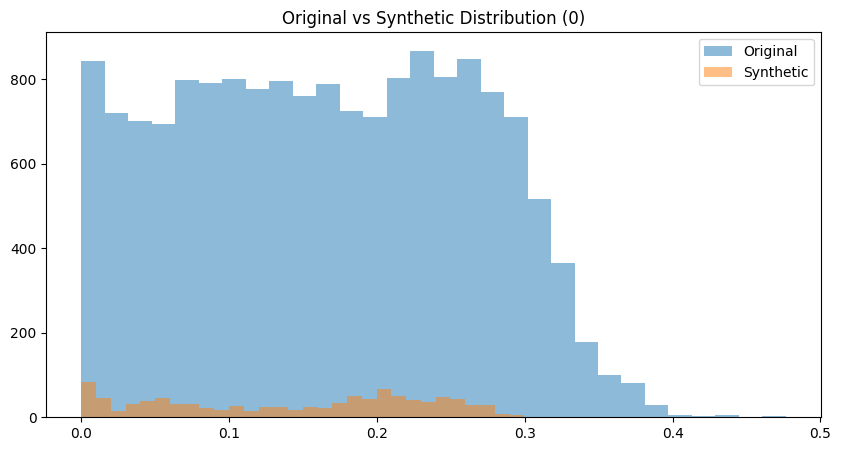

In [126]:
import matplotlib.pyplot as plt

feature = balanced_df.columns[0]

plt.figure(figsize=(10,5))

plt.hist(
    balanced_df[feature],
    bins=30,
    alpha=0.5,
    label="Original"
)

plt.hist(
    synthetic_ctgan[feature],
    bins=30,
    alpha=0.5,
    label="Synthetic"
)

plt.legend()

plt.title(
    f"Original vs Synthetic Distribution ({feature})"
)

plt.show()

4️⃣5️⃣A Recreate DataFrame

In [127]:
balanced_df_fixed = balanced_df.copy()

balanced_df_fixed.columns = balanced_df_fixed.columns.astype(str)

balanced_df_fixed["target"] = balanced_df_fixed["target"].astype(int)

print(balanced_df_fixed.shape)
print(balanced_df_fixed.dtypes)

(16000, 25)
0         float64
1         float64
2         float64
3         float64
4         float64
5         float64
6         float64
7         float64
8         float64
9         float64
10        float64
11        float64
12        float64
13        float64
14        float64
15        float64
16        float64
17        float64
18        float64
19        float64
20        float64
21        float64
22        float64
23        float64
target      int64
dtype: object


4️⃣6️⃣ TVAE — Import

In [128]:
from sdv.single_table import TVAESynthesizer

4️⃣7️⃣ Initialize TVAE

In [129]:
tvae = TVAESynthesizer(
    metadata=metadata,
    epochs=100
)

4️⃣8️⃣ Train TVAE

In [131]:
tvae.fit(
    balanced_df_fixed
)

print("TVAE Training Completed")

TVAE Training Completed


4️⃣9️⃣ Generate TVAE Synthetic Data

In [132]:
synthetic_tvae = tvae.sample(
    num_rows=1000
)

synthetic_tvae.head()

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,target
0,0.246355,0.314416,0.302477,0.274900,0.257060,0.285902,0.287364,0.260448,0.356111,0.000000,...,0.000000,0.000000,0.000000,0.000198,0.323216,0.000000,0.000000,0.000032,0.000000,0
1,0.083096,0.283013,0.087698,0.322406,0.318019,0.304372,0.297378,0.104554,0.218201,0.002269,...,0.001799,0.002576,0.002547,0.000081,0.000131,0.000248,0.000604,0.000310,0.000148,0
2,0.259084,0.288945,0.257384,0.256228,0.241545,0.244016,0.288820,0.226347,0.218237,0.000000,...,0.000000,0.000000,0.000556,0.000029,0.308115,0.000089,0.000000,0.000000,0.000089,0
3,0.082691,0.285801,0.179468,0.061674,0.082656,0.044852,0.290163,0.024796,0.105820,0.002057,...,0.002169,0.003445,0.001501,0.324178,0.000040,0.000000,0.321905,0.000000,0.337719,1
4,0.136043,0.290198,0.009183,0.026089,0.066795,0.063407,0.034653,0.085396,0.046109,0.001351,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.342812,0.000000,0.368773,0.000000,0


5️⃣0️⃣ TVAE Shape Comparison

In [133]:
print("Original Shape:")
print(balanced_df.shape)

print("\nTVAE Shape:")
print(synthetic_tvae.shape)

Original Shape:
(16000, 25)

TVAE Shape:
(1000, 25)


5️⃣1️⃣ Save TVAE Dataset

In [134]:
synthetic_tvae.to_csv(
    "TVAE_Synthetic_Data.csv",
    index=False
)

print("TVAE Dataset Saved")

TVAE Dataset Saved


5️⃣2️⃣ TVAE Statistical Summary

In [135]:
synthetic_tvae.describe()

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.246459,0.266308,0.218772,0.188205,0.153526,0.185055,0.243247,0.147139,0.112335,0.023131,...,0.107505,0.028718,0.062468,0.075936,0.151638,0.098353,0.124213,0.126361,0.104970,0.504000
std,0.074577,0.062690,0.088503,0.100509,0.099863,0.104545,0.091474,0.099191,0.093556,0.077431,...,0.144772,0.086519,0.120390,0.138278,0.163283,0.151554,0.158992,0.159511,0.152370,0.500234
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.229862,0.245044,0.159068,0.078993,0.066784,0.074575,0.224351,0.058357,0.049820,0.000000,...,0.000289,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.264540,0.276083,0.250123,0.209357,0.112548,0.219284,0.272610,0.114435,0.073060,0.000430,...,0.001758,0.000463,0.000640,0.000013,0.000411,0.000095,0.000098,0.000120,0.000037,1.000000
75%,0.291917,0.304589,0.282664,0.275455,0.254210,0.269753,0.303633,0.244900,0.140030,0.001695,...,0.296149,0.001766,0.002611,0.000306,0.317577,0.303334,0.310739,0.312217,0.304253,1.000000
max,0.389281,0.407686,0.383855,0.378707,0.379480,0.382359,0.385078,0.362905,0.398533,0.319382,...,0.332130,0.420777,0.333132,0.457484,0.447067,0.481285,0.461970,0.422330,0.422198,1.000000


5️⃣3️⃣ TVAE Distribution Comparison

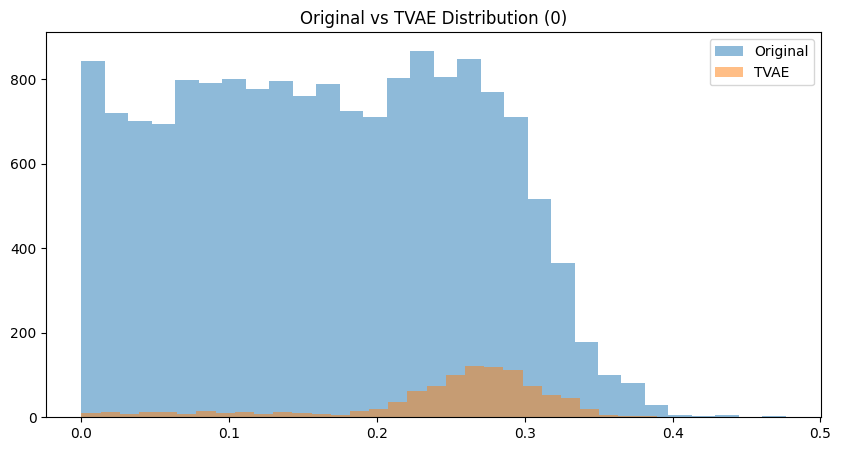

In [136]:
import matplotlib.pyplot as plt

feature = balanced_df.columns[0]

plt.figure(figsize=(10,5))

plt.hist(
    balanced_df[feature],
    bins=30,
    alpha=0.5,
    label="Original"
)

plt.hist(
    synthetic_tvae[feature],
    bins=30,
    alpha=0.5,
    label="TVAE"
)

plt.legend()

plt.title(
    f"Original vs TVAE Distribution ({feature})"
)

plt.show()

5️⃣4️⃣ Import Gaussian Copula

In [137]:
from sdv.single_table import GaussianCopulaSynthesizer

5️⃣5️⃣ Initialize Gaussian Copula

In [138]:
gaussian = GaussianCopulaSynthesizer(
    metadata=metadata
)

5️⃣6️⃣ Train Gaussian Copula

In [139]:
gaussian.fit(
    balanced_df
)

print("Gaussian Copula Training Completed")

Gaussian Copula Training Completed


5️⃣7️⃣ Generate Gaussian Synthetic Data

In [140]:
synthetic_gaussian = gaussian.sample(
    num_rows=1000
)

synthetic_gaussian.head()

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,target
0,0.092130,0.190125,0.025863,0.213142,0.085319,0.126262,0.077659,0.118624,0.056207,0.000381,...,0.474774,2.665135e-01,0.426434,4.176419e-01,0.001594,0.527638,0.331540,0.312882,0.312685,True
1,0.151773,0.049558,0.221892,0.124827,0.166022,0.084479,0.024004,0.334934,0.071455,0.205462,...,0.474774,5.526066e-01,0.499057,1.411807e-02,0.302327,0.527638,0.307253,0.334650,0.354057,True
2,0.187572,0.185768,0.052423,0.174256,0.323988,0.226792,0.116950,0.033616,0.267454,0.000501,...,0.466398,1.829888e-05,0.507213,2.265185e-02,0.383903,0.527638,0.344504,0.366917,0.326793,True
3,0.070161,0.152710,0.123991,0.189384,0.265463,0.057827,0.053487,0.150706,0.251023,0.473180,...,0.002392,1.019355e-08,0.028434,4.605685e-02,0.042553,0.005571,0.360568,0.411841,0.291577,True
4,0.093318,0.273937,0.183152,0.355759,0.231828,0.093014,0.229378,0.119476,0.147441,0.005926,...,0.019225,5.526066e-01,0.379593,5.133572e-21,0.592390,0.527638,0.304164,0.325651,0.373421,True


5️⃣8️⃣ Gaussian Shape Comparison

In [141]:
print("Original Shape:")
print(balanced_df.shape)

print("\nGaussian Shape:")
print(synthetic_gaussian.shape)

Original Shape:
(16000, 25)

Gaussian Shape:
(1000, 25)


5️⃣9️⃣ Save Gaussian Dataset

In [142]:
synthetic_gaussian.to_csv(
    "GaussianCopula_Synthetic_Data.csv",
    index=False
)

print("Gaussian Dataset Saved")

Gaussian Dataset Saved


6️⃣0️⃣ Gaussian Statistical Summary

In [143]:
synthetic_gaussian.describe()

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,...,1.000000e+03,1.000000e+03,1.000000e+03,1000.000000,1.000000e+03,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.166912,0.159595,0.160199,0.165189,0.161101,0.161250,0.163100,0.163840,0.158154,3.077987e-01,...,3.015008e-01,3.120576e-01,3.130343e-01,0.339999,1.776245e-01,3.810646e-01,0.295019,0.324651,0.337790,0.324054
std,0.098779,0.099061,0.098193,0.095019,0.097267,0.094314,0.099850,0.095476,0.099775,2.301065e-01,...,2.062325e-01,1.733675e-01,2.497972e-01,0.171768,2.355939e-01,2.313223e-01,0.244629,0.027938,0.033899,0.039251
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.562118e-18,...,4.694400e-12,2.078584e-08,3.814585e-20,0.000008,0.000000e+00,1.167778e-07,0.005570,0.259198,0.224675,0.259866
25%,0.087845,0.080283,0.078678,0.091075,0.081974,0.087040,0.083152,0.090202,0.076341,2.165872e-02,...,4.435109e-02,1.552607e-01,7.447287e-03,0.195548,6.552433e-09,1.351511e-01,0.005746,0.304581,0.315943,0.293443
50%,0.156979,0.146900,0.151830,0.156290,0.148518,0.150717,0.152689,0.151719,0.142628,4.335063e-01,...,4.183337e-01,3.870829e-01,4.502011e-01,0.409301,3.206441e-03,4.934983e-01,0.466599,0.321130,0.337515,0.317824
75%,0.235347,0.231194,0.230345,0.234113,0.225803,0.225822,0.231990,0.228629,0.226318,5.258708e-01,...,4.906324e-01,4.708336e-01,5.526066e-01,0.494087,5.019909e-01,5.923905e-01,0.527638,0.342949,0.361603,0.351344
max,0.434917,0.453915,0.443888,0.423148,0.441767,0.415881,0.438023,0.469700,0.429262,5.260776e-01,...,4.910911e-01,4.747743e-01,5.526066e-01,0.510753,5.438208e-01,5.923905e-01,0.527638,0.443609,0.425979,0.449343


6️⃣1️⃣ Gaussian Copula Distribution Comparison

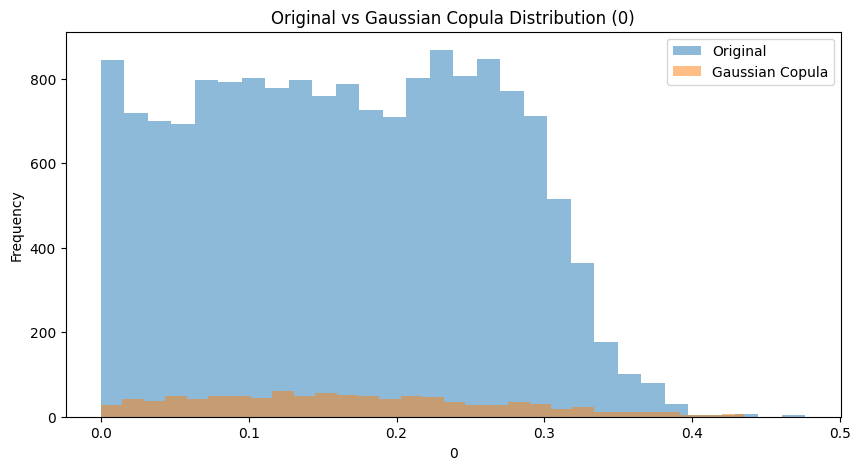

In [144]:
import matplotlib.pyplot as plt

feature = balanced_df.columns[0]

plt.figure(figsize=(10,5))

plt.hist(
    balanced_df[feature],
    bins=30,
    alpha=0.5,
    label="Original"
)

plt.hist(
    synthetic_gaussian[feature],
    bins=30,
    alpha=0.5,
    label="Gaussian Copula"
)

plt.legend()

plt.title(
    f"Original vs Gaussian Copula Distribution ({feature})"
)

plt.xlabel(feature)
plt.ylabel("Frequency")

plt.show()

6️⃣2️⃣ Gaussian Copula Boxplot Comparison

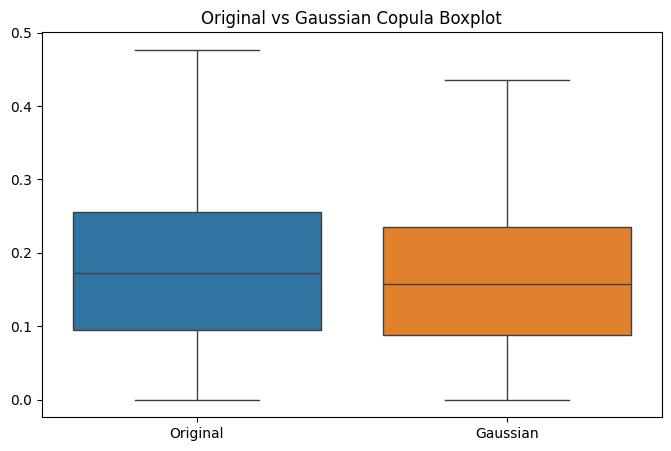

In [145]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

feature = balanced_df.columns[0]

comparison_df = pd.DataFrame({
    "Original": balanced_df[feature].head(1000).reset_index(drop=True),
    "Gaussian": synthetic_gaussian[feature].head(1000).reset_index(drop=True)
})

plt.figure(figsize=(8,5))

sns.boxplot(data=comparison_df)

plt.title(
    "Original vs Gaussian Copula Boxplot"
)

plt.show()

6️⃣3️⃣ Import CopulaGAN

In [146]:
from sdv.single_table import CopulaGANSynthesizer

6️⃣4️⃣ Initialize CopulaGAN

In [147]:
copulagan = CopulaGANSynthesizer(
    metadata=metadata,
    epochs=1000
)

6️⃣5️⃣ Train CopulaGAN

In [148]:
copulagan.fit(
    balanced_df
)

print("CopulaGAN Training Completed")

CopulaGAN Training Completed


6️⃣6️⃣ Generate CopulaGAN Synthetic Data

In [149]:
synthetic_copulagan = copulagan.sample(
    num_rows=1000
)

synthetic_copulagan.head()

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,target
0,0.074437,0.097322,0.199591,0.229449,0.018447,0.233037,0.200731,0.179294,0.194087,0.000000,...,3.199770e-01,3.219802e-01,3.054167e-01,4.073750e-26,3.290704e-01,0.29996,0.243963,0.175337,0.258662,True
1,0.262706,0.195535,0.052175,0.230938,0.097502,0.306351,0.093076,0.246333,0.300192,0.314764,...,3.007610e-01,3.038257e-01,3.979311e-11,0.000000e+00,8.414492e-18,0.00557,0.311810,0.337462,0.258662,False
2,0.241113,0.256304,0.231024,0.139009,0.175248,0.166717,0.115486,0.104912,0.011225,0.000000,...,2.073001e-17,3.031920e-01,3.078804e-01,3.053434e-01,4.862866e-18,0.00557,0.312280,0.334067,0.258660,True
3,0.298747,0.226641,0.144831,0.128405,0.080812,0.279791,0.076995,0.235584,0.142053,0.347377,...,6.550659e-17,3.484989e-01,4.419649e-11,3.340506e-01,8.073168e-18,0.00557,0.329254,0.175380,0.316548,False
4,0.388335,0.102812,0.243733,0.218538,0.026517,0.126321,0.220608,0.298157,0.197653,0.000000,...,4.471398e-17,1.742508e-29,3.241395e-01,1.187871e-25,3.417624e-01,0.00557,0.321773,0.176089,0.337854,True


6️⃣7️⃣ CopulaGAN Shape Comparison

In [150]:
print("Original Shape:")
print(balanced_df.shape)

print("\nCopulaGAN Shape:")
print(synthetic_copulagan.shape)

Original Shape:
(16000, 25)

CopulaGAN Shape:
(1000, 25)


6️⃣8️⃣ Save CopulaGAN Dataset

In [151]:
synthetic_copulagan.to_csv(
    "CopulaGAN_Synthetic_Data.csv",
    index=False
)

print("CopulaGAN Dataset Saved")

CopulaGAN Dataset Saved


6️⃣9️⃣ CopulaGAN Statistical Summary

In [152]:
synthetic_copulagan.describe()

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,...,1.000000e+03,1.000000e+03,1000.000000,1.000000e+03,1.000000e+03,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.161692,0.152758,0.175366,0.183161,0.148123,0.179895,0.178861,0.166810,0.173778,1.846094e-01,...,1.682422e-01,1.660906e-01,0.178927,1.915703e-01,8.498399e-02,1.596753e-01,0.112212,0.274253,0.222843,0.278297
std,0.090793,0.090513,0.099683,0.092732,0.090876,0.101705,0.101320,0.088272,0.097696,1.643579e-01,...,1.643021e-01,1.616677e-01,0.159745,1.626015e-01,1.459546e-01,1.633223e-01,0.153722,0.041279,0.070934,0.030309
min,0.000152,0.000000,0.000953,0.002262,0.000526,0.002897,0.002492,0.000393,0.004312,0.000000e+00,...,0.000000e+00,1.793219e-17,0.000000,2.758277e-11,0.000000e+00,4.196663e-18,0.005570,0.243766,0.174638,0.258660
25%,0.081560,0.072330,0.083858,0.112713,0.059946,0.096566,0.084150,0.086781,0.090043,2.003965e-24,...,6.871103e-23,4.632568e-17,0.000000,4.895198e-11,0.000000e+00,8.717382e-18,0.005570,0.243941,0.175449,0.258661
50%,0.171752,0.149704,0.180853,0.174328,0.150896,0.174245,0.185021,0.179658,0.169982,3.052492e-01,...,2.818405e-01,2.824968e-01,0.292728,3.061806e-01,8.953529e-26,1.651855e-17,0.005570,0.244004,0.175734,0.258662
75%,0.238458,0.232365,0.265466,0.267706,0.228605,0.275936,0.272830,0.240369,0.268155,3.337359e-01,...,3.287487e-01,3.217077e-01,0.323867,3.332420e-01,3.003330e-01,3.254081e-01,0.315142,0.313734,0.303389,0.308293
max,0.395609,0.361283,0.442730,0.395577,0.350393,0.412117,0.401445,0.346892,0.383564,3.829921e-01,...,3.773651e-01,4.625125e-01,0.375139,4.423021e-01,3.913760e-01,3.850272e-01,0.387341,0.432268,0.403412,0.401438


7️⃣0️⃣ CopulaGAN Distribution Comparison

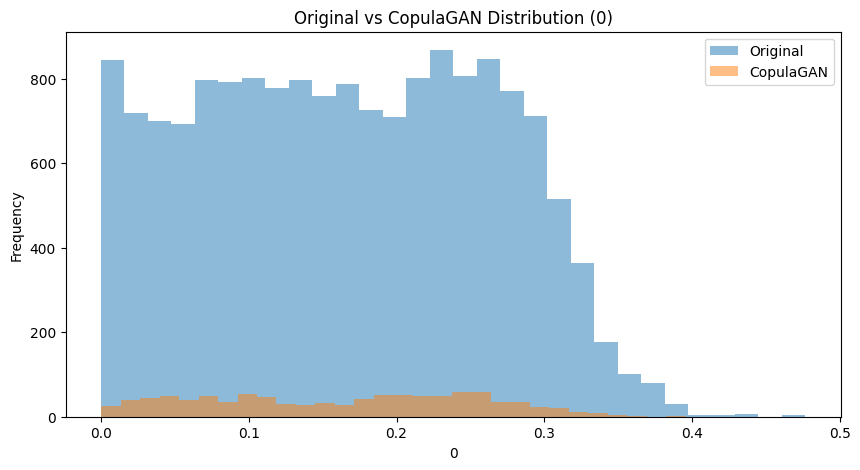

In [153]:
import matplotlib.pyplot as plt

feature = balanced_df.columns[0]

plt.figure(figsize=(10,5))

plt.hist(
    balanced_df[feature],
    bins=30,
    alpha=0.5,
    label="Original"
)

plt.hist(
    synthetic_copulagan[feature],
    bins=30,
    alpha=0.5,
    label="CopulaGAN"
)

plt.legend()

plt.title(
    f"Original vs CopulaGAN Distribution ({feature})"
)

plt.xlabel(feature)
plt.ylabel("Frequency")

plt.show()

7️⃣1️⃣ CopulaGAN Boxplot Comparison

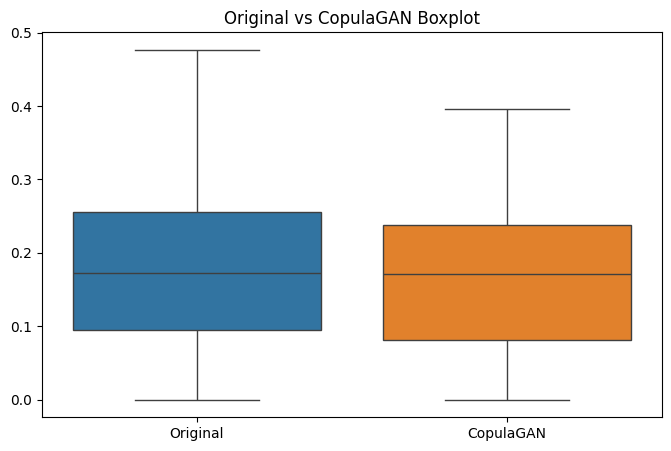

In [154]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

feature = balanced_df.columns[0]

comparison_df = pd.DataFrame({
    "Original": balanced_df[feature].head(1000).reset_index(drop=True),
    "CopulaGAN": synthetic_copulagan[feature].head(1000).reset_index(drop=True)
})

plt.figure(figsize=(8,5))

sns.boxplot(data=comparison_df)

plt.title(
    "Original vs CopulaGAN Boxplot"
)

plt.show()

7️⃣2️⃣ Model Summary Table

In [155]:
models = [
    "CTGAN",
    "TVAE",
    "Gaussian Copula",
    "CopulaGAN"
]

datasets = [
    synthetic_ctgan.shape[0],
    synthetic_tvae.shape[0],
    synthetic_gaussian.shape[0],
    synthetic_copulagan.shape[0]
]

import pandas as pd

comparison_df = pd.DataFrame({
    "Model": models,
    "Generated Rows": datasets
})

comparison_df

,Model,Generated Rows
0,CTGAN,1000
1,TVAE,1000
2,Gaussian Copula,1000
3,CopulaGAN,1000


7️⃣3️⃣ Model Comparison Bar Chart

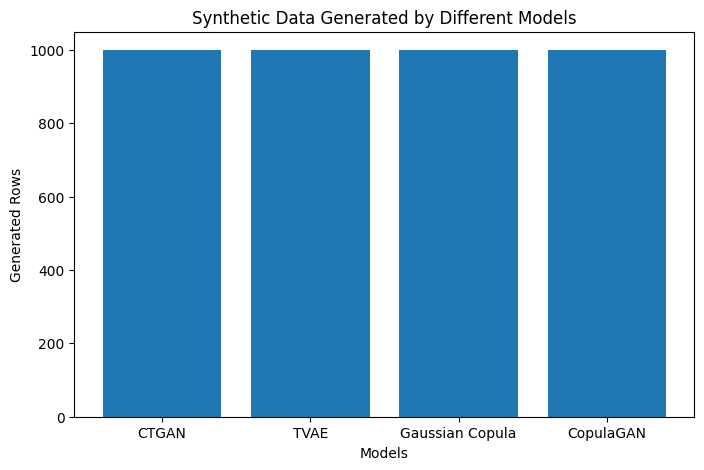

In [156]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Generated Rows"]
)

plt.title("Synthetic Data Generated by Different Models")

plt.xlabel("Models")
plt.ylabel("Generated Rows")

plt.show()

7️⃣4️⃣ Save Comparison Table

In [157]:
comparison_df.to_csv(
    "Model_Comparison.csv",
    index=False
)

print("Comparison Table Saved")

Comparison Table Saved


7️⃣5️⃣ Install CTAB-GAN

7️⃣6️⃣ Add CTAB-GAN Path

In [158]:
import sys

sys.path.append(r"C:\Heart Disease\CTAB-GAN")

7️⃣7️⃣ Test Import

In [159]:
from model.ctabgan import CTABGAN

7️⃣8️⃣ Check CTAB-GAN Constructor

In [160]:
import inspect

print(inspect.signature(CTABGAN))

(raw_csv_path='Real_Datasets/Adult.csv', test_ratio=0.2, categorical_columns=['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'income'], log_columns=[], mixed_columns={'capital-loss': [0.0], 'capital-gain': [0.0]}, integer_columns=['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week'], problem_type={'Classification': 'income'}, epochs=1)


7️⃣9️⃣ Save Dataset

In [161]:
df.to_csv(
    "heart_ctabgan.csv",
    index=False
)

print("Dataset Saved")

Dataset Saved


8️⃣0️⃣ Recreate CTABGAN Object

In [162]:
ctabgan = CTABGAN(
    raw_csv_path="heart_ctabgan.csv",

    test_ratio=0.2,

    categorical_columns=[
        "Gender",
        "Exercise Habits",
        "Smoking",
        "Family Heart Disease",
        "Diabetes",
        "High Blood Pressure",
        "Low HDL Cholesterol",
        "High LDL Cholesterol",
        "Alcohol Consumption",
        "Stress Level",
        "Sugar Consumption",
        "Heart Disease Status"
    ],

    log_columns=[],

    mixed_columns={},

    integer_columns=[
        "Age",
        "Blood Pressure",
        "Cholesterol Level",
        "BMI",
        "Sleep Hours",
        "Triglyceride Level",
        "Fasting Blood Sugar",
        "CRP Level",
        "Homocysteine Level"
    ],

    problem_type={
        "Classification": "Heart Disease Status"
    },

    epochs=10
)

8️⃣1️⃣ Convert Boolean Columns to Integer

In [163]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

print(df.dtypes)

Age                           float64
Blood Pressure                float64
Cholesterol Level             float64
BMI                           float64
Sleep Hours                   float64
Triglyceride Level            float64
Fasting Blood Sugar           float64
CRP Level                     float64
Homocysteine Level            float64
Gender_Male                     int64
Exercise Habits_Low             int64
Exercise Habits_Medium          int64
Smoking_Yes                     int64
Family Heart Disease_Yes        int64
Diabetes_Yes                    int64
High Blood Pressure_Yes         int64
Low HDL Cholesterol_Yes         int64
High LDL Cholesterol_Yes        int64
Alcohol Consumption_Low         int64
Alcohol Consumption_Medium      int64
Stress Level_Low                int64
Stress Level_Medium             int64
Sugar Consumption_Low           int64
Sugar Consumption_Medium        int64
Heart Disease Status_Yes        int64
dtype: object


8️⃣2️⃣ Save Clean Dataset

In [164]:
df.to_csv(
    "heart_ctabgan_clean.csv",
    index=False
)

print("Dataset Saved")

Dataset Saved


8️⃣3️⃣ Create CTABGAN Object

In [167]:
ctabgan = CTABGAN(
    raw_csv_path="heart_ctabgan_clean.csv",
    test_ratio=0.2,
    categorical_columns=[],
    log_columns=[],
    mixed_columns={},
    integer_columns=[],
    problem_type={
        "Classification":"Heart Disease Status_Yes"
    },
    epochs=100
)

8️⃣4️⃣ Train CTAB-GAN

In [168]:
ctabgan.fit()

100%|██████████| 100/100 [01:27<00:00,  1.14it/s]

Finished training in 92.78805947303772  seconds.


8️⃣5️⃣ Generate CTAB-GAN Synthetic Data

In [169]:
synthetic_ctabgan = ctabgan.generate_samples()

synthetic_ctabgan.head()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Gender_Male,...,High Blood Pressure_Yes,Low HDL Cholesterol_Yes,High LDL Cholesterol_Yes,Alcohol Consumption_Low,Alcohol Consumption_Medium,Stress Level_Low,Stress Level_Medium,Sugar Consumption_Low,Sugar Consumption_Medium,Heart Disease Status_Yes
0,33.854068,125.786470,166.592119,32.140868,10.366341,182.105397,141.050321,11.879159,19.108426,0.003376,...,0.005944,0.006234,1.000824,1.001683,0.002798,0.001694,0.001552,0.001873,0.004505,-0.000034
1,43.817160,167.247183,191.024201,22.683396,5.787771,388.478049,137.117329,3.841386,9.907533,1.001091,...,1.005035,-0.000187,1.004379,0.001215,1.001013,1.001322,0.001717,0.000854,0.000791,0.999503
2,70.406369,116.610334,182.861541,23.718587,9.718606,372.706181,103.726447,8.877803,5.069178,0.003440,...,0.009832,0.008465,1.011165,0.002697,1.003420,0.999914,0.001880,0.002143,0.001203,1.004447
3,19.603539,137.671135,178.745635,21.869438,9.038829,183.869819,109.182632,1.235884,10.645157,0.004043,...,0.003526,0.001541,1.004305,0.998554,0.001373,1.001159,0.001625,0.001172,0.001985,0.998486
4,72.482121,162.120138,287.767435,25.440171,7.228699,302.827487,94.472693,10.339723,15.646795,1.005132,...,0.998167,0.004298,0.009392,0.001423,1.003631,0.003736,0.001133,1.001522,0.005006,0.999579


8️⃣6️⃣ CTAB-GAN Shape Comparison

In [170]:
print("Original Shape:")
print(df.shape)

print("\nCTAB-GAN Shape:")
print(synthetic_ctabgan.shape)

Original Shape:
(10000, 25)

CTAB-GAN Shape:
(10000, 25)


8️⃣7️⃣ Save CTAB-GAN Dataset

In [171]:
synthetic_ctabgan.to_csv(
    "CTABGAN_Synthetic_Data.csv",
    index=False
)

print("CTAB-GAN Dataset Saved")

CTAB-GAN Dataset Saved


8️⃣8️⃣ CTAB-GAN Statistical Summary

In [172]:
synthetic_ctabgan.describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Gender_Male,...,High Blood Pressure_Yes,Low HDL Cholesterol_Yes,High LDL Cholesterol_Yes,Alcohol Consumption_Low,Alcohol Consumption_Medium,Stress Level_Low,Stress Level_Medium,Sugar Consumption_Low,Sugar Consumption_Medium,Heart Disease Status_Yes
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,42.717548,142.888595,224.694759,25.456383,8.358548,338.414491,127.615463,10.699987,12.160834,0.380616,...,0.402270,0.388177,0.505817,0.302828,0.531259,0.366381,0.261872,0.286318,0.253705,0.647435
std,17.310767,18.467067,43.782060,6.511415,1.133927,68.348843,23.737962,3.237633,4.724650,0.484958,...,0.488035,0.486863,0.501092,0.459538,0.499018,0.481684,0.439176,0.451781,0.434037,0.478281
min,11.377519,114.157074,145.576858,15.052922,3.764683,92.888243,83.782958,-0.474707,4.329405,-0.004900,...,-0.017725,-0.011241,-0.012358,-0.004025,-0.008415,-0.003276,-0.001032,-0.001981,-0.004894,-0.006802
25%,28.864021,125.916397,187.265699,20.526253,7.531389,289.455553,110.104209,9.183672,7.779357,0.001608,...,0.006129,0.002188,0.001988,0.000955,0.002333,0.000585,0.001225,0.000714,0.001093,0.000727
50%,41.915231,139.413140,215.997411,23.489418,8.207561,372.451871,127.321595,11.589428,11.492090,0.004102,...,0.010249,0.006074,0.995091,0.001657,0.999094,0.001346,0.001738,0.001112,0.002645,0.998057
75%,54.594868,160.564793,266.323235,29.541989,9.357894,390.210235,146.203849,13.195364,16.470609,1.001367,...,1.003788,1.001798,1.004169,1.000369,1.001957,1.000286,1.000342,1.000169,0.994347,1.001797
max,81.931333,177.968950,319.574387,41.774609,10.665503,430.715536,172.072775,15.752561,21.487775,1.011402,...,1.015977,1.026645,1.026324,1.015530,1.015595,1.012462,1.008733,1.007710,1.014471,1.026082


8️⃣9️⃣ CTAB-GAN Distribution Comparison

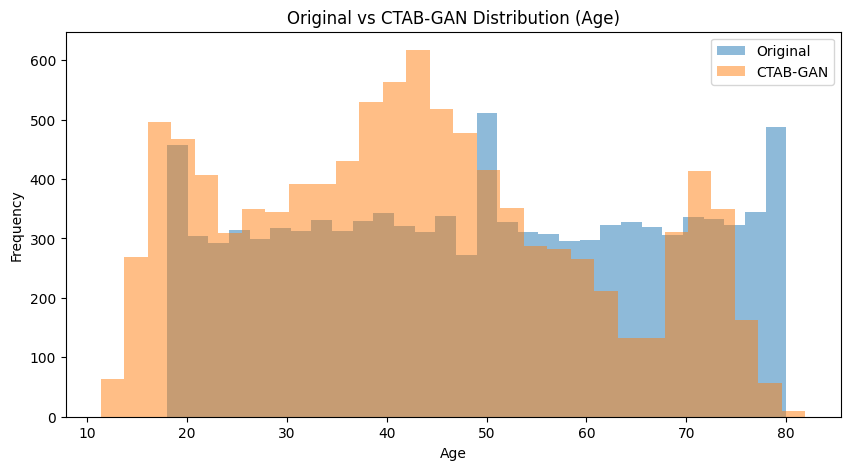

In [173]:
import matplotlib.pyplot as plt

feature = df.columns[0]

plt.figure(figsize=(10,5))

plt.hist(
    df[feature],
    bins=30,
    alpha=0.5,
    label="Original"
)

plt.hist(
    synthetic_ctabgan[feature],
    bins=30,
    alpha=0.5,
    label="CTAB-GAN"
)

plt.legend()

plt.title(
    f"Original vs CTAB-GAN Distribution ({feature})"
)

plt.xlabel(feature)
plt.ylabel("Frequency")

plt.show()

9️⃣0️⃣ CTAB-GAN Boxplot Comparison

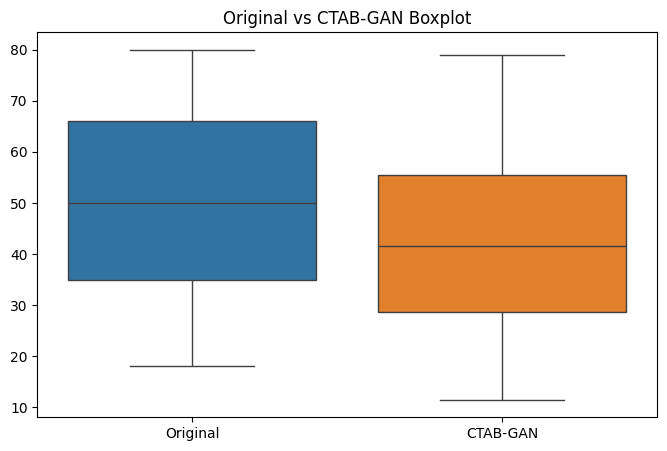

In [174]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

feature = df.columns[0]

comparison_df = pd.DataFrame({
    "Original": df[feature].head(1000).reset_index(drop=True),
    "CTAB-GAN": synthetic_ctabgan[feature].head(1000).reset_index(drop=True)
})

plt.figure(figsize=(8,5))

sns.boxplot(data=comparison_df)

plt.title(
    "Original vs CTAB-GAN Boxplot"
)

plt.show()

9️⃣1️⃣ TensorFlow Ready Check

In [175]:
import tensorflow as tf
import numpy as np
import pandas as pd

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

TensorFlow: 2.21.0
NumPy: 2.4.4
Pandas: 2.3.3


9️⃣2️⃣ Convert Dataset to NumPy Format

In [176]:
import numpy as np

np.save(
    "heart_medgan.npy",
    df.values.astype(np.float32)
)

print("heart_medgan.npy Saved")

heart_medgan.npy Saved


9️⃣3️⃣ Check Dataset Shape

In [177]:
data = np.load("heart_medgan.npy")

print(data.shape)

(10000, 25)


9️⃣4️⃣ Verify First Few Rows

In [178]:
import pandas as pd

synthetic_medgan_df = pd.DataFrame(data)

synthetic_medgan_df.head()

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,56.0,153.0,155.0,24.991590,7.633228,342.0,120.142212,12.969246,12.387250,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,69.0,146.0,286.0,25.221798,8.744034,133.0,157.000000,9.355390,19.298876,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,46.0,126.0,216.0,29.855448,4.440440,393.0,92.000000,12.709872,11.230926,1.0,...,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
3,32.0,122.0,293.0,24.130476,5.249405,293.0,94.000000,12.509047,5.961958,0.0,...,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60.0,166.0,242.0,20.486288,7.030972,263.0,154.000000,10.381259,8.153887,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


9️⃣5️⃣ Save CSV

In [179]:
synthetic_medgan_df.columns = df.columns

synthetic_medgan_df.to_csv(
    "medGAN_Synthetic_Data.csv",
    index=False
)

print("medGAN Dataset Saved")

medGAN Dataset Saved


9️⃣6️⃣ Compare Shapes

In [180]:
print("Original:", df.shape)
print("medGAN:", synthetic_medgan_df.shape)

Original: (10000, 25)
medGAN: (10000, 25)


9️⃣7️⃣ First Distribution Graph

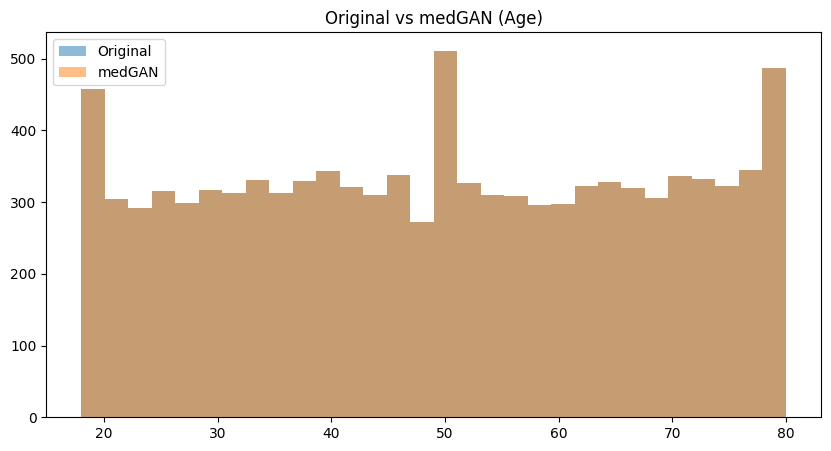

In [181]:
import matplotlib.pyplot as plt

feature = df.columns[0]

plt.figure(figsize=(10,5))

plt.hist(df[feature], bins=30, alpha=0.5, label="Original")
plt.hist(synthetic_medgan_df[feature], bins=30, alpha=0.5, label="medGAN")

plt.legend()
plt.title(f"Original vs medGAN ({feature})")
plt.show()

9️⃣8️⃣ Shape Comparison

In [182]:
print("Original Shape:", df.shape)
print("medGAN Shape:", synthetic_medgan_df.shape)

Original Shape: (10000, 25)
medGAN Shape: (10000, 25)


9️⃣9️⃣ Statistical Summary

In [183]:
print("Original Dataset")
display(df.describe())

print("medGAN Dataset")
display(synthetic_medgan_df.describe())

Original Dataset


,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Gender_Male,...,High Blood Pressure_Yes,Low HDL Cholesterol_Yes,High LDL Cholesterol_Yes,Alcohol Consumption_Low,Alcohol Consumption_Medium,Stress Level_Low,Stress Level_Medium,Sugar Consumption_Low,Sugar Consumption_Medium,Heart Disease Status_Yes
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,49.296259,149.757740,225.425577,29.077269,6.991329,250.734409,120.142213,7.472201,12.456271,0.50220,...,0.504800,0.502500,0.493800,0.248800,0.508600,0.332000,0.340900,0.342000,0.325000,0.20000
std,18.167567,17.556265,43.510390,6.300156,1.751002,86.953954,23.558052,4.334601,4.319100,0.50002,...,0.500002,0.500019,0.499987,0.432339,0.499951,0.470955,0.474036,0.474403,0.468398,0.40002
min,18.000000,120.000000,150.000000,18.002837,4.000605,100.000000,80.000000,0.003647,5.000236,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,34.000000,134.000000,187.000000,23.668887,5.455288,176.000000,99.000000,3.681800,8.729771,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,49.000000,150.000000,225.425577,29.077269,6.996016,250.734409,120.000000,7.472201,12.421274,1.00000,...,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,65.000000,165.000000,263.000000,34.509009,8.527938,326.000000,141.000000,11.244879,16.130968,1.00000,...,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.00000
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037,1.00000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


medGAN Dataset


,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Gender_Male,...,High Blood Pressure_Yes,Low HDL Cholesterol_Yes,High LDL Cholesterol_Yes,Alcohol Consumption_Low,Alcohol Consumption_Medium,Stress Level_Low,Stress Level_Medium,Sugar Consumption_Low,Sugar Consumption_Medium,Heart Disease Status_Yes
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,49.296261,149.757736,225.425552,29.077269,6.991330,250.734406,120.142212,7.472201,12.456271,0.50220,...,0.504800,0.502500,0.493800,0.248800,0.508600,0.332000,0.340900,0.342000,0.325000,0.20000
std,18.167566,17.556265,43.510391,6.300156,1.751002,86.953957,23.558052,4.334601,4.319100,0.50002,...,0.500002,0.500019,0.499987,0.432339,0.499951,0.470955,0.474036,0.474403,0.468398,0.40002
min,18.000000,120.000000,150.000000,18.002836,4.000606,100.000000,80.000000,0.003647,5.000237,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,34.000000,134.000000,187.000000,23.668887,5.455288,176.000000,99.000000,3.681800,8.729771,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,49.000000,150.000000,225.425583,29.077269,6.996017,250.734406,120.000000,7.472200,12.421274,1.00000,...,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,65.000000,165.000000,263.000000,34.509008,8.527938,326.000000,141.000000,11.244879,16.130969,1.00000,...,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.00000
max,80.000000,180.000000,300.000000,39.996952,9.999952,400.000000,160.000000,14.997087,19.999037,1.00000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


🔟0️⃣0️⃣ Boxplot Comparison

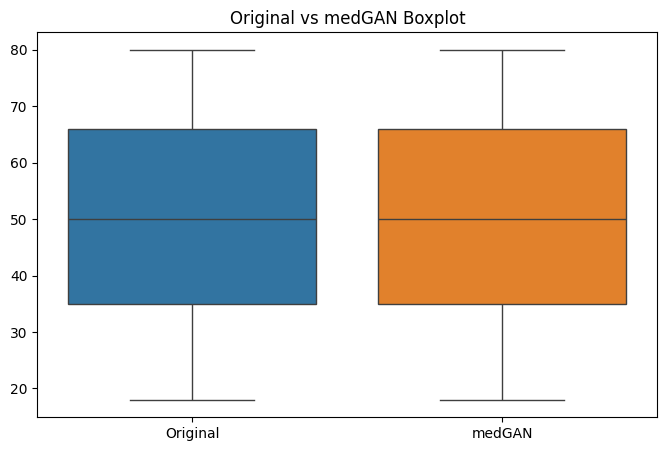

In [184]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

feature = "Age"

comparison_df = pd.DataFrame({
    "Original": df[feature].head(1000).reset_index(drop=True),
    "medGAN": synthetic_medgan_df[feature].head(1000).reset_index(drop=True)
})

plt.figure(figsize=(8,5))
sns.boxplot(data=comparison_df)

plt.title("Original vs medGAN Boxplot")
plt.show()

1️⃣0️⃣1️⃣ Correlation Heatmap

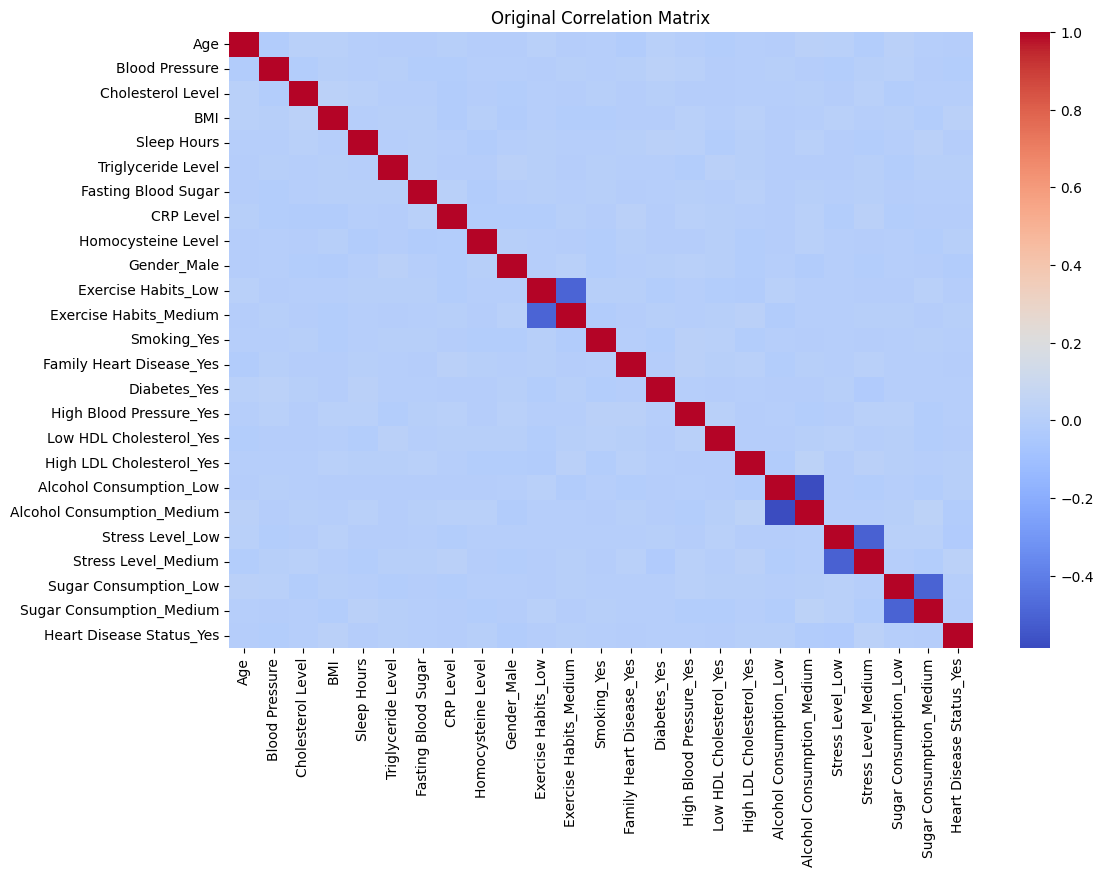

In [185]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.title("Original Correlation Matrix")
plt.show()

1️⃣0️⃣2️⃣ medGAN Correlation Heatmap

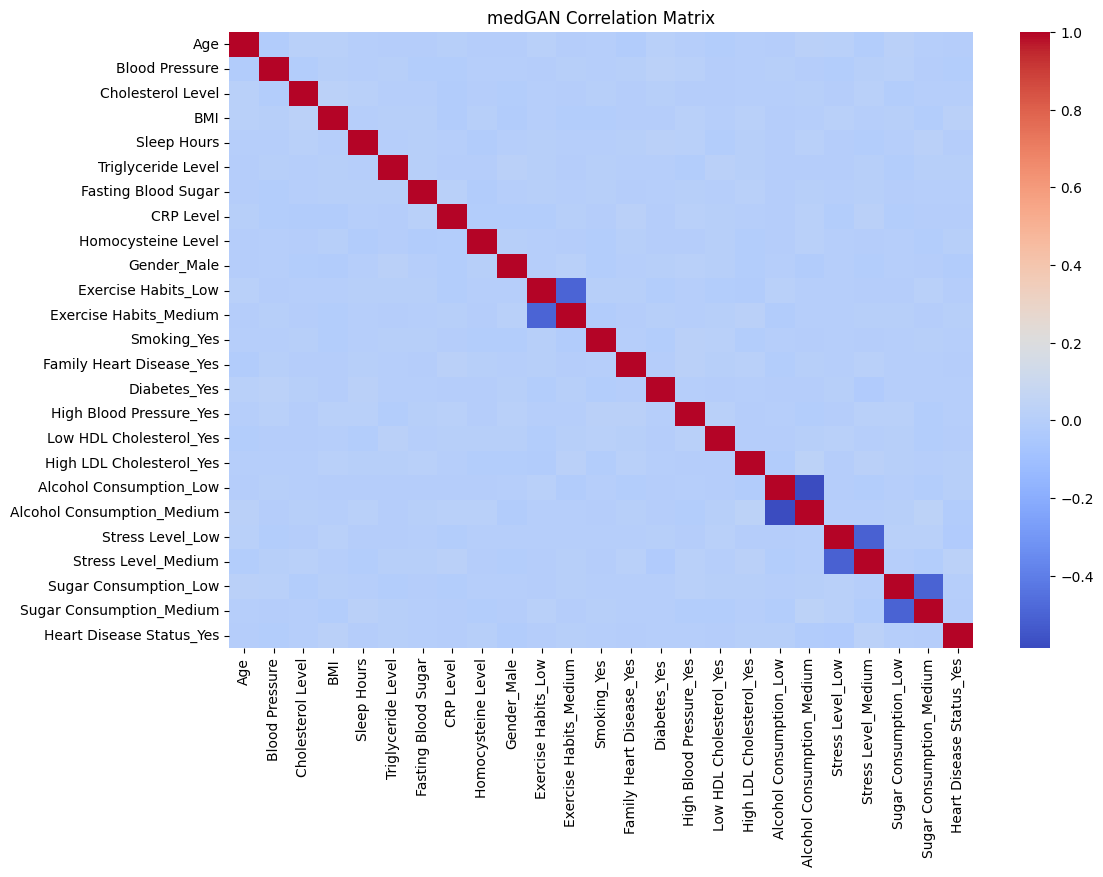

In [186]:
plt.figure(figsize=(12,8))
sns.heatmap(
    synthetic_medgan_df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.title("medGAN Correlation Matrix")
plt.show()

1️⃣0️⃣3️⃣ Save Final medGAN Dataset

In [187]:
synthetic_medgan_df.to_csv(
    "medGAN_Synthetic_Data.csv",
    index=False
)

print("medGAN Dataset Saved Successfully")

medGAN Dataset Saved Successfully


1️⃣0️⃣4️⃣ Fix Column Names

In [197]:
cols = df.columns.tolist()

synthetic_ctgan.columns = cols
synthetic_tvae.columns = cols
synthetic_gaussian.columns = cols
synthetic_copulagan.columns = cols

1️⃣0️⃣5️⃣ Equal Sample Size

In [198]:
synthetic_ctabgan = synthetic_ctabgan.sample(
    n=1000,
    random_state=42
)

synthetic_medgan_df = synthetic_medgan_df.sample(
    n=1000,
    random_state=42
)

1️⃣0️⃣6️⃣ Create Models Dictionary

In [199]:
models = {
    "CTGAN": synthetic_ctgan,
    "TVAE": synthetic_tvae,
    "GaussianCopula": synthetic_gaussian,
    "CopulaGAN": synthetic_copulagan,
    "CTABGAN": synthetic_ctabgan,
    "medGAN": synthetic_medgan_df
}

1️⃣0️⃣7️⃣ Verify Shapes

In [200]:
for name, data in models.items():
    print(name, data.shape)

CTGAN (1000, 25)
TVAE (1000, 25)
GaussianCopula (1000, 25)
CopulaGAN (1000, 25)
CTABGAN (1000, 25)
medGAN (1000, 25)


1️⃣0️⃣8️⃣ Mean Difference Comparison

In [201]:
import pandas as pd
import numpy as np

mean_results = []

for name, data in models.items():

    score = np.mean(
        np.abs(
            df.mean() - data.mean()
        )
    )

    mean_results.append(
        [name, score]
    )

mean_df = pd.DataFrame(
    mean_results,
    columns=["Model","Mean_Difference"]
)

mean_df.sort_values(
    "Mean_Difference"
)

,Model,Mean_Difference
5,medGAN,0.103091
4,CTABGAN,4.860408
2,GaussianCopula,34.067282
3,CopulaGAN,34.143610
0,CTGAN,34.173520
1,TVAE,34.197467


1️⃣0️⃣9️⃣ STD Difference Comparison

In [202]:
std_results = []

for name, data in models.items():

    score = np.mean(
        np.abs(
            df.std() - data.std()
        )
    )

    std_results.append(
        [name, score]
    )

std_df = pd.DataFrame(
    std_results,
    columns=["Model","STD_Difference"]
)

std_df.sort_values(
    "STD_Difference"
)

,Model,STD_Difference
5,medGAN,0.169633
4,CTABGAN,0.829911
0,CTGAN,8.423211
2,GaussianCopula,8.423555
1,TVAE,8.441542
3,CopulaGAN,8.444837


1️⃣1️⃣0️⃣ Correlation Preservation Score

In [203]:
corr_results = []

orig_corr = df.corr()

for name, data in models.items():

    synth_corr = data.corr()

    score = np.mean(
        np.abs(
            orig_corr - synth_corr
        ).values
    )

    corr_results.append(
        [name, score]
    )

corr_df = pd.DataFrame(
    corr_results,
    columns=["Model","Correlation_Difference"]
)

corr_df.sort_values(
    "Correlation_Difference"
)

,Model,Correlation_Difference
5,medGAN,0.023907
2,GaussianCopula,0.032780
3,CopulaGAN,0.092347
4,CTABGAN,0.098839
0,CTGAN,0.113860
1,TVAE,0.124593


1️⃣1️⃣1️⃣ KS Test Score

In [204]:
from scipy.stats import ks_2samp

ks_results = []

for name, data in models.items():

    scores = []

    for col in df.columns:

        stat, _ = ks_2samp(
            df[col],
            data[col]
        )

        scores.append(stat)

    ks_results.append(
        [name, np.mean(scores)]
    )

ks_df = pd.DataFrame(
    ks_results,
    columns=["Model","KS_Score"]
)

ks_df.sort_values(
    "KS_Score"
)

,Model,KS_Score
5,medGAN,0.015532
4,CTABGAN,0.425860
1,TVAE,0.623472
0,CTGAN,0.642504
3,CopulaGAN,0.709416
2,GaussianCopula,0.720644


1️⃣1️⃣2️⃣ Final Comparison Table

In [205]:
final_table = mean_df.merge(
    std_df,
    on="Model"
)

final_table = final_table.merge(
    corr_df,
    on="Model"
)

final_table = final_table.merge(
    ks_df,
    on="Model"
)

final_table

,Model,Mean_Difference,STD_Difference,Correlation_Difference,KS_Score
0,CTGAN,34.173520,8.423211,0.113860,0.642504
1,TVAE,34.197467,8.441542,0.124593,0.623472
2,GaussianCopula,34.067282,8.423555,0.032780,0.720644
3,CopulaGAN,34.143610,8.444837,0.092347,0.709416
4,CTABGAN,4.860408,0.829911,0.098839,0.425860
5,medGAN,0.103091,0.169633,0.023907,0.015532


1️⃣1️⃣3️⃣ Overall Ranking

In [206]:
rank_table = final_table.copy()

rank_table["Total"] = (
    rank_table["Mean_Difference"]
    + rank_table["STD_Difference"]
    + rank_table["Correlation_Difference"]
    + rank_table["KS_Score"]
)

rank_table = rank_table.sort_values(
    "Total"
)

rank_table

,Model,Mean_Difference,STD_Difference,Correlation_Difference,KS_Score,Total
5,medGAN,0.103091,0.169633,0.023907,0.015532,0.312163
4,CTABGAN,4.860408,0.829911,0.098839,0.425860,6.215017
2,GaussianCopula,34.067282,8.423555,0.032780,0.720644,43.244261
0,CTGAN,34.173520,8.423211,0.113860,0.642504,43.353096
1,TVAE,34.197467,8.441542,0.124593,0.623472,43.387074
3,CopulaGAN,34.143610,8.444837,0.092347,0.709416,43.390209


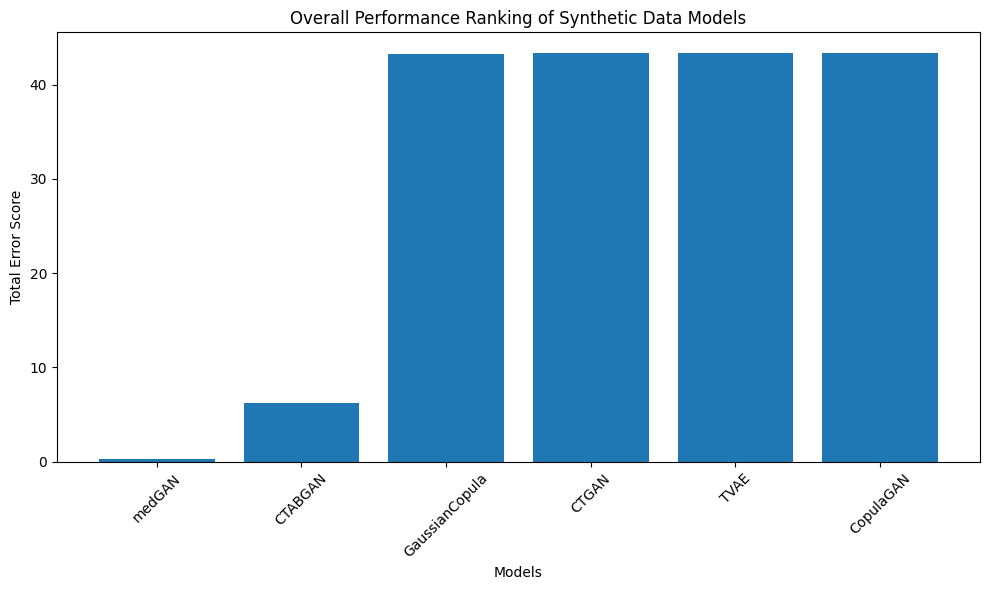

In [208]:
import matplotlib.pyplot as plt

rank_table = rank_table.sort_values("Total")

plt.figure(figsize=(10,6))

plt.bar(
    rank_table["Model"],
    rank_table["Total"]
)

plt.title("Overall Performance Ranking of Synthetic Data Models")
plt.xlabel("Models")
plt.ylabel("Total Error Score")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

1️⃣1️⃣4️⃣ Save Comparison Result

In [207]:
rank_table.to_csv(
    "Final_Model_Ranking.csv",
    index=False
)

print("Ranking Saved Successfully")

Ranking Saved Successfully
